# Parse lcls2CP_usrtrack_25_tab.lis

In [54]:
import re
from pathlib import Path
import pandas as pd

filepath = Path(__file__).parent / 'lcls2CP_usrtrack_25_tab.lis' if '__file__' in dir() else Path('/Users/arjun/Python_Codes_Refactored/analysis/lcls2CP_usrtrack_25_tab.lis')

with open(filepath, 'r') as f:
    lines = f.readlines()

# Match delimiter lines; only keep tracks starting with 'TrackN' (TrackNeut*)
detector_pattern = re.compile(r'#\s+Detector\s+n:\s+(\d+)\s+(Track\S+)')

dataframes = {}  # keyed by track name
df_list = []     # ordered list of (track_name, df)

for i, line in enumerate(lines):
    m = detector_pattern.search(line)
    if m:
        track_name = m.group(2).strip()
        if not track_name.startswith('TrackN'):
            continue

        # i+1 is the '# N. of energy intervals' line — skip it
        # data starts at i+2, runs for 251 rows
        data_start = i + 2
        data_lines = lines[data_start : data_start + 251]

        rows = []
        for dl in data_lines:
            nums = dl.split()
            if len(nums) < 3:
                continue
            upper  = int(float(nums[0]) * 1000)
            lower  = int(float(nums[1]) * 1000)
            weight = float(nums[2])
            rows.append({'upper': upper, 'lower': lower, 'weight': weight})

        df = pd.DataFrame(rows, columns=['upper', 'lower', 'weight'])
        dataframes[track_name] = df
        df_list.append((track_name, df))

print(f'Parsed {len(dataframes)} TrackN detectors:')
for name, _ in df_list:
    print(f'  {name}')


Parsed 11 TrackN detectors:
  TrackNeut
  TrackNeut1
  TrackNeut2
  TrackNeut3
  TrackNeut4
  TrackNeut5
  TrackNeut6
  TrackNeut7
  TrackNeut8
  TrackNeut9
  TrackNet10


In [55]:
dataframes['TrackNeut']

,upper,lower,weight
0,0,0,1.719193
1,0,1,0.984255
2,1,2,0.465527
3,2,3,0.220192
4,3,4,0.116670
...,...,...,...
246,245,246,0.000097
247,246,247,0.000044
248,247,248,0.000004
249,248,249,0.000066


In [56]:
# Preview first dataframe
name, df = df_list[0]
print(f'{name}  —  shape: {df.shape}')
df.head(10)

TrackNeut  —  shape: (251, 3)


,upper,lower,weight
0,0,0,1.719193
1,0,1,0.984255
2,1,2,0.465527
3,2,3,0.220192
4,3,4,0.116670
5,4,5,0.067171
6,5,6,0.042540
7,6,7,0.028040
8,7,8,0.022093
9,8,9,0.017084


In [57]:
# Access any track by name, e.g.:
dataframes['TrackNeut']

,upper,lower,weight
0,0,0,1.719193
1,0,1,0.984255
2,1,2,0.465527
3,2,3,0.220192
4,3,4,0.116670
...,...,...,...
246,245,246,0.000097
247,246,247,0.000044
248,247,248,0.000004
249,248,249,0.000066


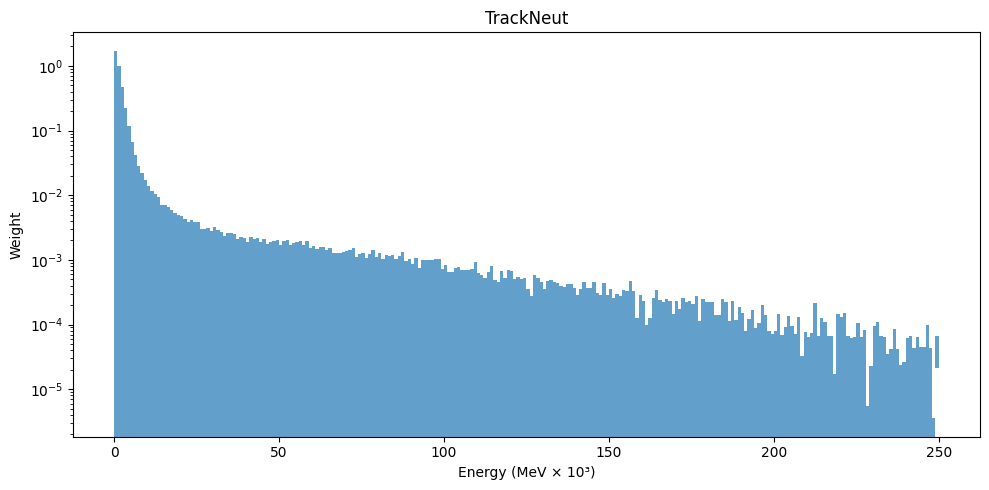

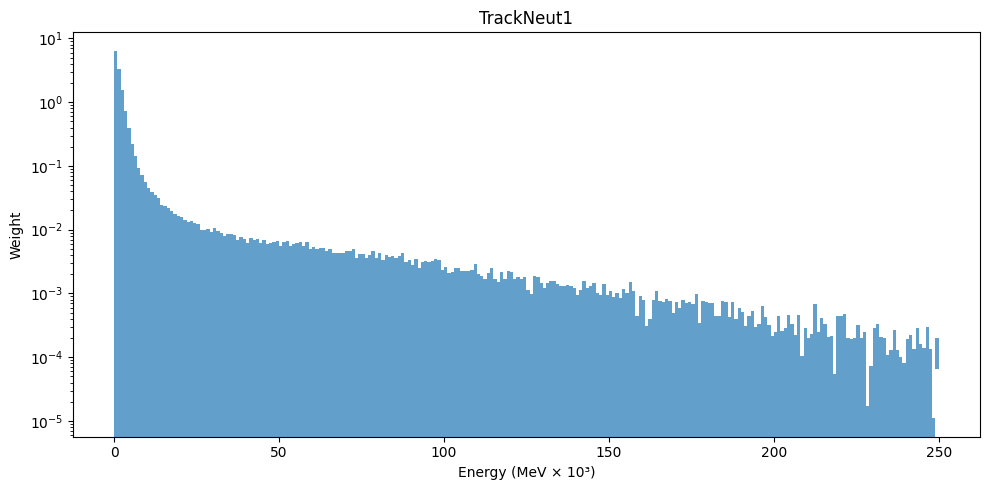

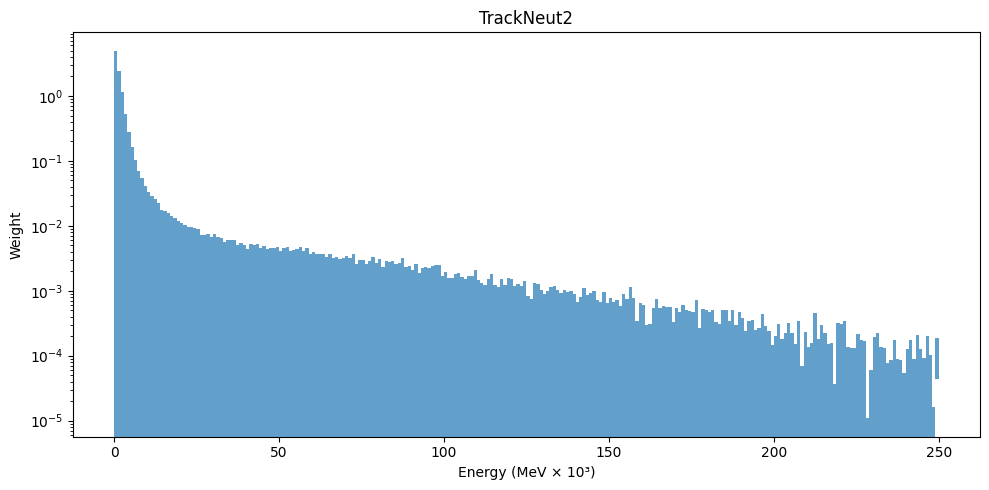

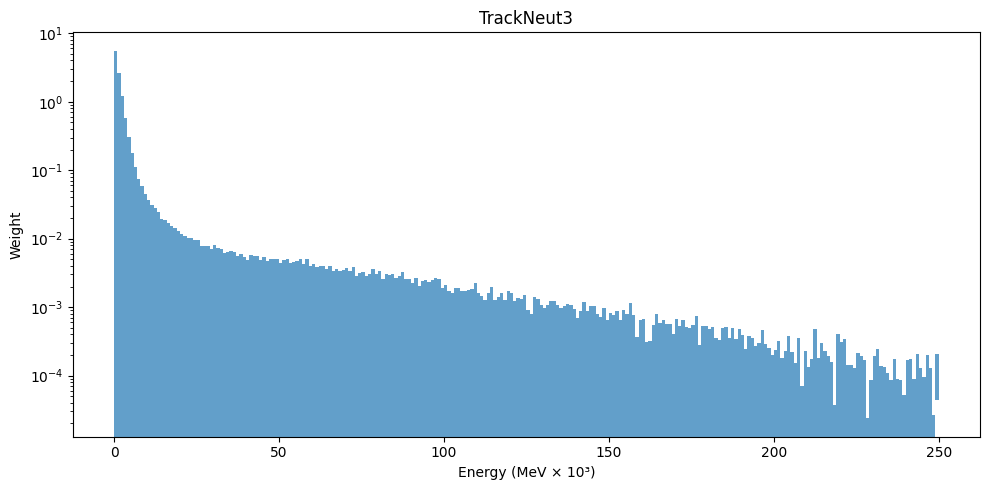

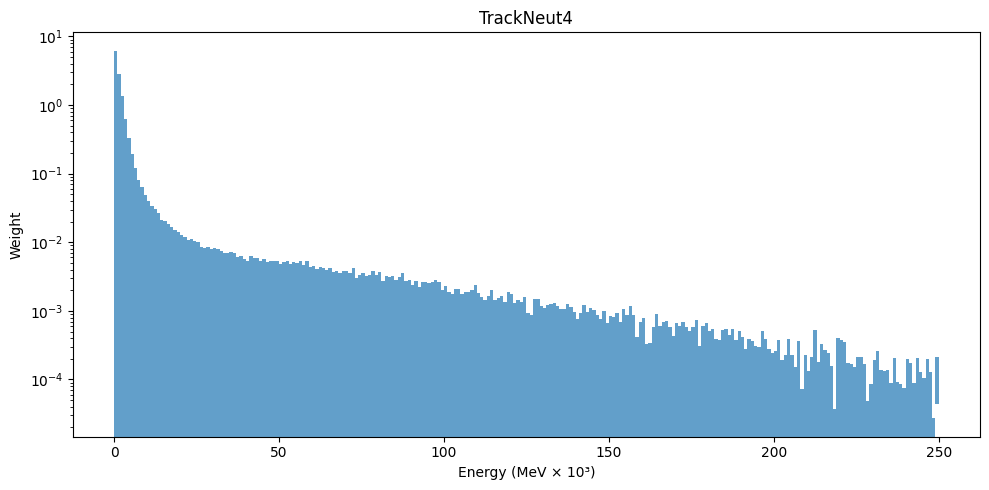

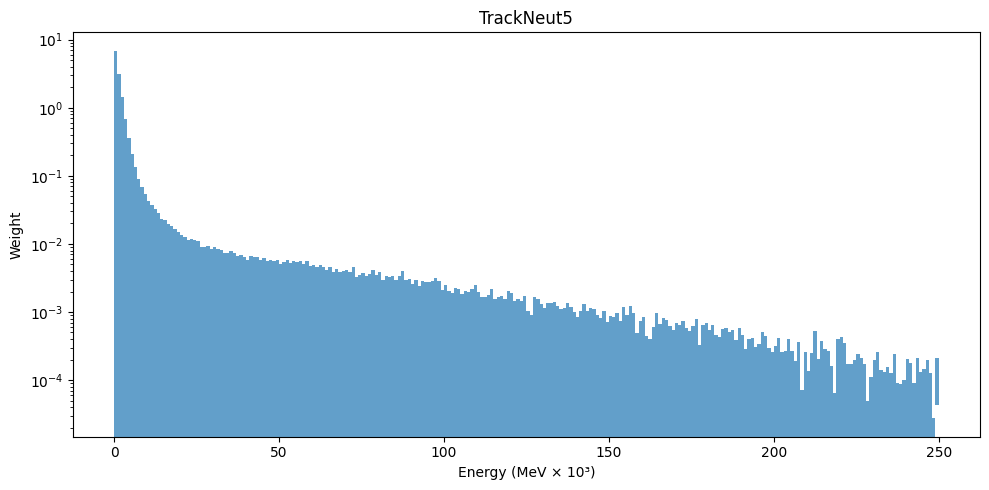

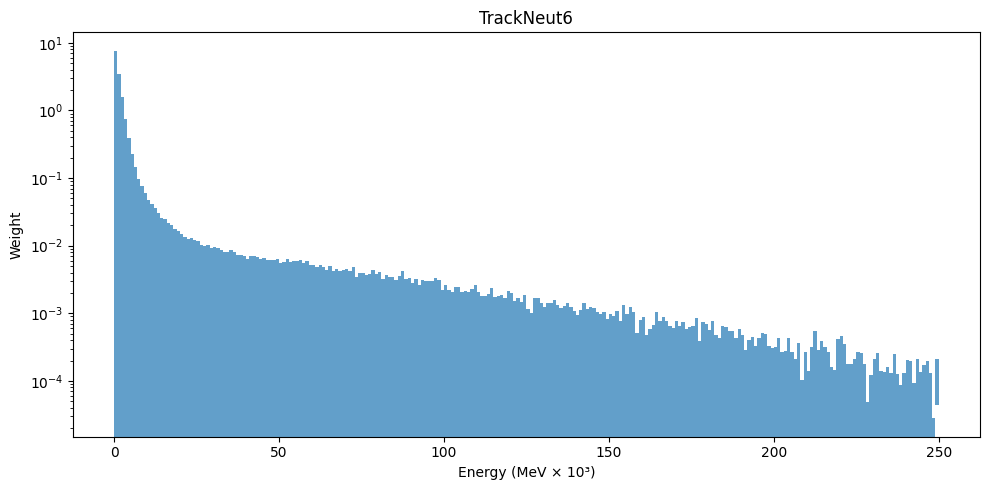

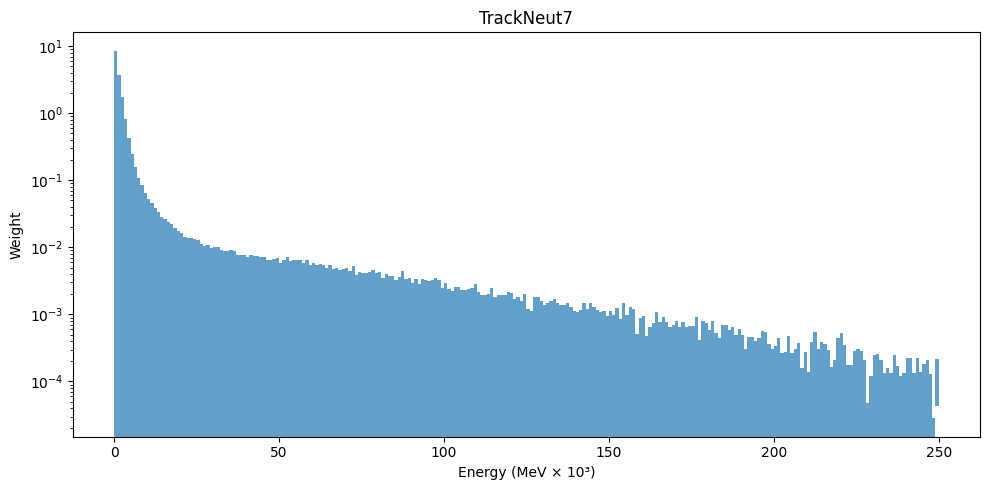

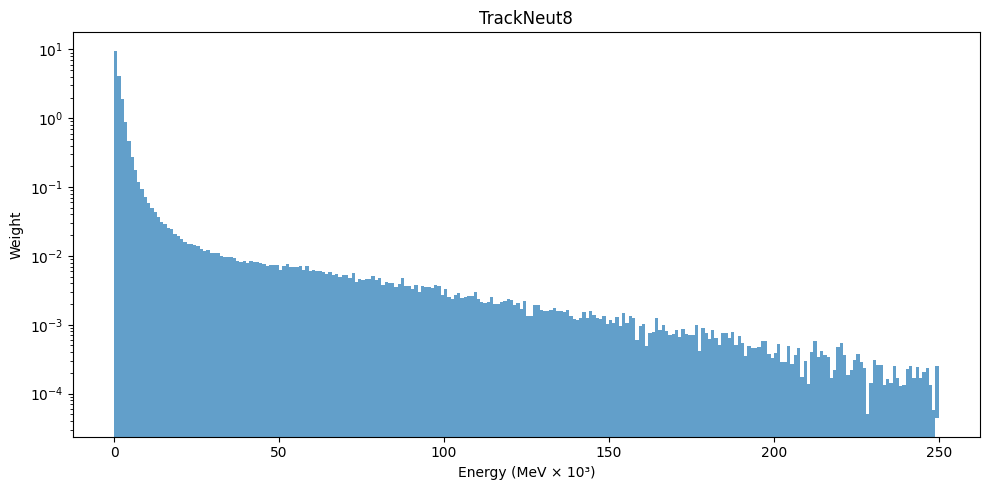

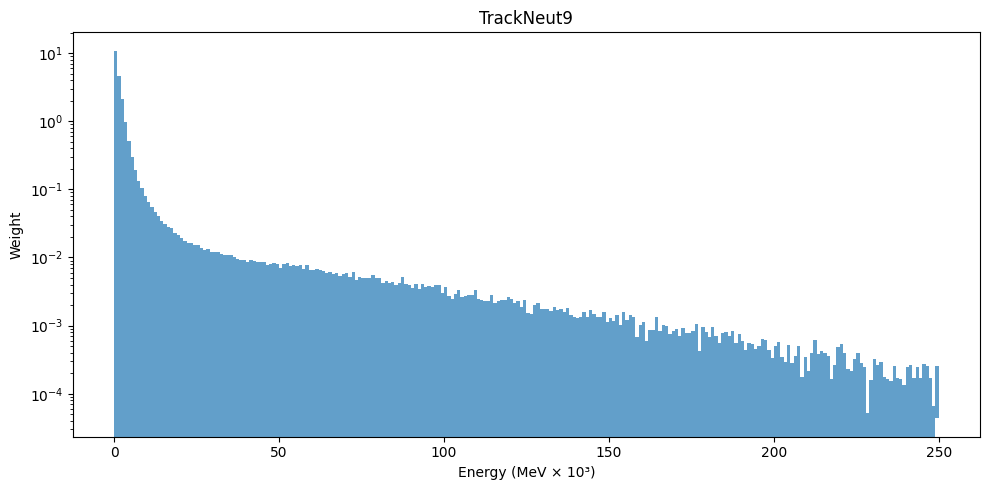

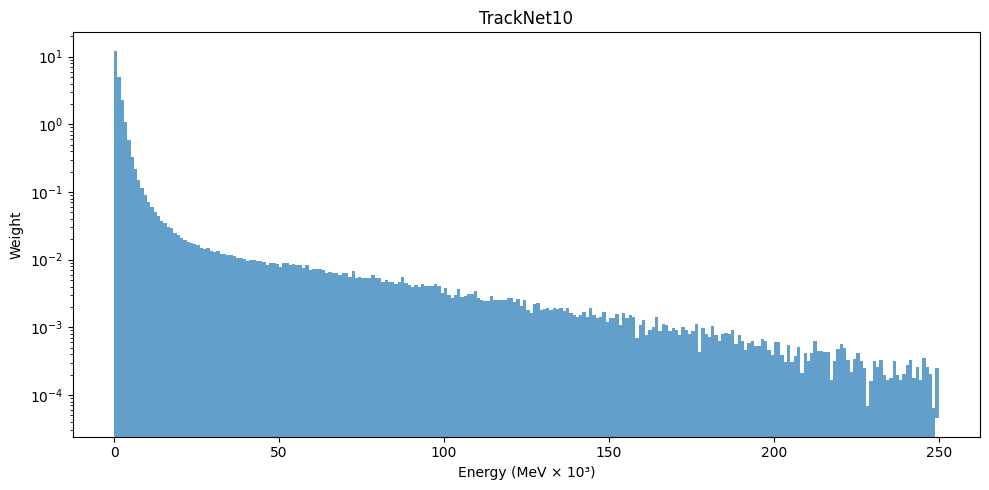

In [58]:
import matplotlib.pyplot as plt
import numpy as np

for track_name, df in df_list:
    bin_edges = np.append(df['lower'].values, df['upper'].iloc[-1])

    fig, ax = plt.subplots(figsize=(10, 5))
    ax.stairs(df['weight'].values, bin_edges, fill=True, alpha=0.7)
    ax.set_xlabel('Energy (MeV × 10³)')
    ax.set_ylabel('Weight')
    ax.set_title(track_name)
    ax.set_yscale('log')
    plt.tight_layout()
    plt.show()

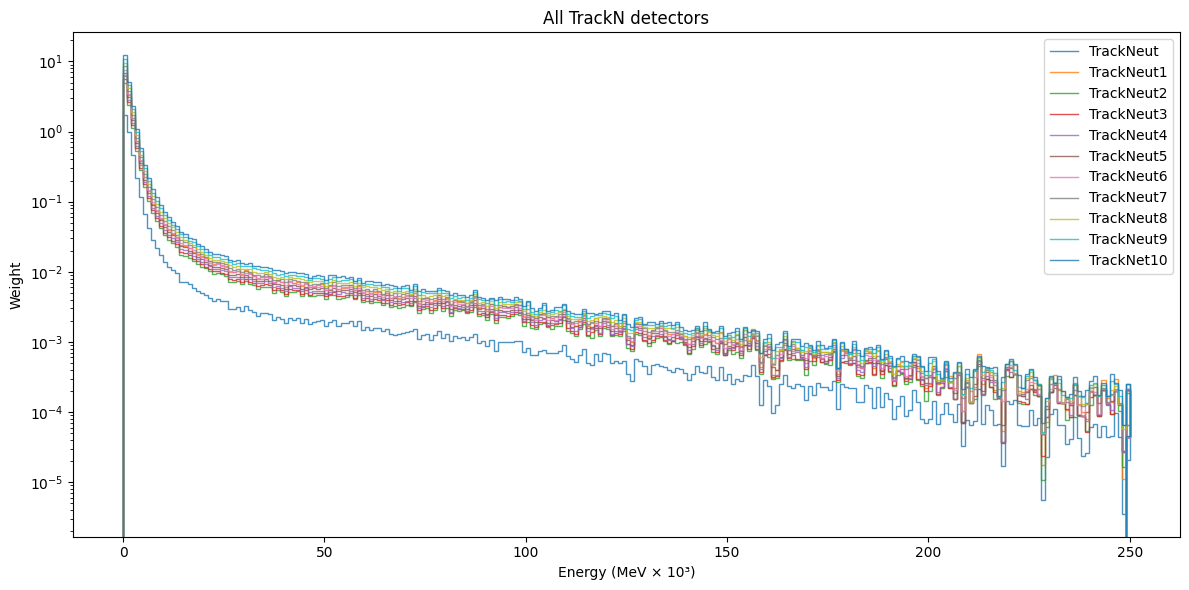

In [59]:
fig, ax = plt.subplots(figsize=(12, 6))

for track_name, df in df_list:
    bin_edges = np.append(df['lower'].values, df['upper'].iloc[-1])
    ax.stairs(df['weight'].values, bin_edges, label=track_name, alpha=0.8)

ax.set_xlabel('Energy (MeV × 10³)')
ax.set_ylabel('Weight')
ax.set_title('All TrackN detectors')
ax.set_yscale('log')
ax.legend()
plt.tight_layout()
plt.show()

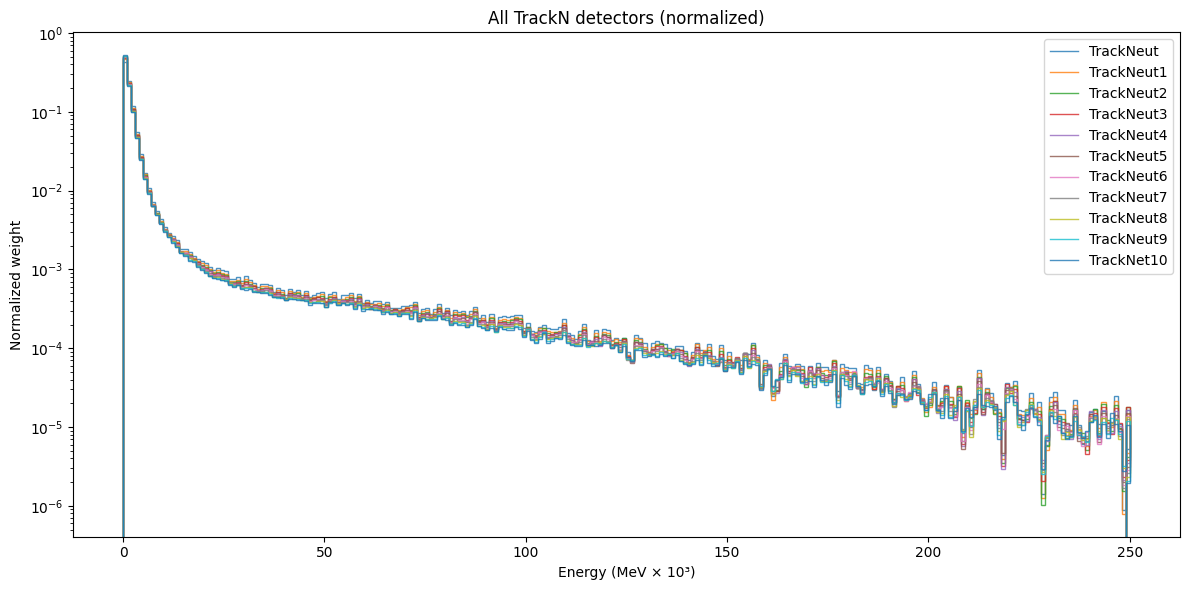

In [60]:
fig, ax = plt.subplots(figsize=(12, 6))

for track_name, df in df_list:
    bin_edges = np.append(df['lower'].values, df['upper'].iloc[-1])
    norm_weights = df['weight'].values / df['weight'].sum()
    ax.stairs(norm_weights, bin_edges, label=track_name, alpha=0.8)

ax.set_xlabel('Energy (MeV × 10³)')
ax.set_ylabel('Normalized weight')
ax.set_title('All TrackN detectors (normalized)')
ax.set_yscale('log')
ax.legend()
plt.tight_layout()
plt.show()

In [61]:
(df['weight'] / df['weight'].sum()).values

array([5.22642249e-01, 2.15119032e-01, 9.92136275e-02, 4.66338592e-02,
       2.46591079e-02, 1.41231712e-02, 9.18441281e-03, 6.36734975e-03,
       4.90828268e-03, 3.79374164e-03, 3.02773763e-03, 2.55791975e-03,
       2.18210952e-03, 1.91007152e-03, 1.59494572e-03, 1.46363070e-03,
       1.27765127e-03, 1.24021839e-03, 1.07276026e-03, 9.87592681e-04,
       9.01672036e-04, 8.26138014e-04, 7.72457746e-04, 7.57993233e-04,
       7.31563441e-04, 7.09676220e-04, 6.37211807e-04, 6.04708158e-04,
       6.30162370e-04, 5.64468645e-04, 5.53061035e-04, 5.66130439e-04,
       5.16146559e-04, 5.23059136e-04, 5.01308433e-04, 5.01592768e-04,
       4.75723885e-04, 4.48399478e-04, 4.46643376e-04, 4.35467062e-04,
       4.06271621e-04, 4.23810983e-04, 4.26541249e-04, 4.06417899e-04,
       4.09603684e-04, 3.96749606e-04, 3.53383123e-04, 3.74674892e-04,
       3.77911503e-04, 3.70162652e-04, 3.29969761e-04, 3.85282699e-04,
       3.86308017e-04, 3.53831936e-04, 3.70541458e-04, 3.52958178e-04,
      

Gamma fit:  A=1.0375e-01±2.50e-03  k=-0.0981±0.0179  θ=-447261488.5322±390336881763770.8125


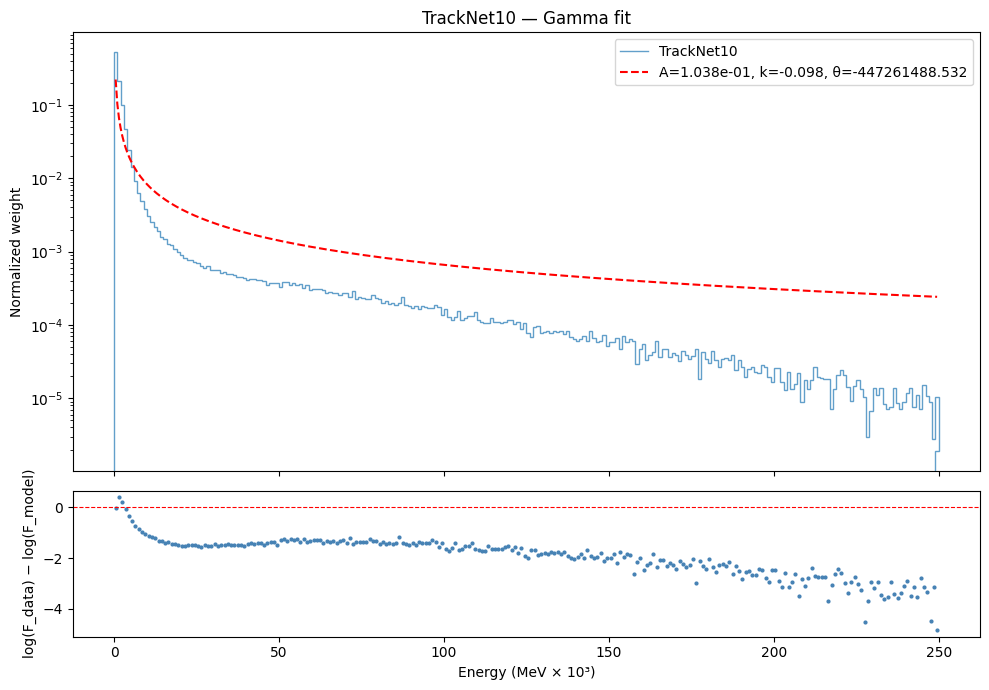

In [62]:
from scipy.optimize import curve_fit

track_name, df = df_list[10]   # TrackNet10
E_centers = ((df['lower'] + df['upper']) / 2).values
TrackNeut10 = (df['weight'] / df['weight'].sum()).values

# all valid bins (E > 0, weight > 0)
mask = (TrackNeut10 > 0) & (E_centers > 0)
E_fit = E_centers[mask]
F_fit = TrackNeut10[mask]

def gamma_func(E, A, k, theta):
    return A * E**(k - 1) * np.exp(-E / theta)

p0 = [F_fit.max(), 1.5, E_fit.mean()]
popt, pcov = curve_fit(gamma_func, E_fit, F_fit, p0=p0, maxfev=20000)
A_fit, k_fit, theta_fit = popt
perr = np.sqrt(np.diag(pcov))
print(f'Gamma fit:  A={A_fit:.4e}±{perr[0]:.2e}  k={k_fit:.4f}±{perr[1]:.4f}  θ={theta_fit:.4f}±{perr[2]:.4f}')

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 7), sharex=True,
                               gridspec_kw={'height_ratios': [3, 1]})

bin_edges = np.append(df['lower'].values, df['upper'].iloc[-1])
ax1.stairs(TrackNeut10, bin_edges, label=track_name, alpha=0.7)
E_smooth = np.linspace(E_fit.min(), E_fit.max(), 500)
ax1.plot(E_smooth, gamma_func(E_smooth, *popt), 'r--',
         label=f'A={A_fit:.3e}, k={k_fit:.3f}, θ={theta_fit:.3f}')
ax1.set_ylabel('Normalized weight')
ax1.set_yscale('log')
ax1.set_title(f'{track_name} — Gamma fit')
ax1.legend()

log_res = np.log(F_fit) - np.log(gamma_func(E_fit, *popt))
ax2.scatter(E_fit, log_res, s=4, color='steelblue')
ax2.axhline(0, color='r', linestyle='--', linewidth=0.8)
ax2.set_ylabel('log(F_data) − log(F_model)')
ax2.set_xlabel('Energy (MeV × 10³)')
plt.tight_layout()
plt.show()

Lognormal fit:  A=3.9729e-01±1.29e-03  μ=0.1728±0.0027  σ=1.0450±0.0052


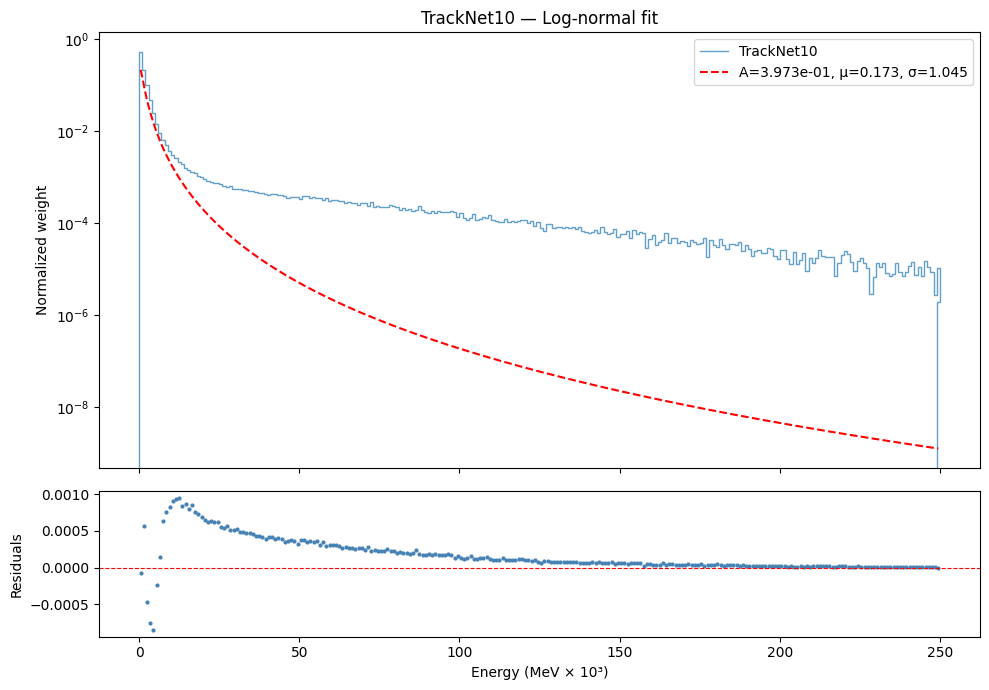

In [63]:
def lognormal_func(E, A, mu, sigma):
    return (A / (E * sigma * np.sqrt(2 * np.pi))) * np.exp(-((np.log(E) - mu)**2) / (2 * sigma**2))
# use same mask (E > 0, weight > 0)
p0 = [F_fit.max(), np.log(E_fit.mean()), 1.0]
popt_ln, pcov_ln = curve_fit(lognormal_func, E_fit, F_fit, p0=p0, maxfev=20000)
A_ln, mu_ln, sigma_ln = popt_ln
perr_ln = np.sqrt(np.diag(pcov_ln))
print(f'Lognormal fit:  A={A_ln:.4e}±{perr_ln[0]:.2e}  μ={mu_ln:.4f}±{perr_ln[1]:.4f}  σ={sigma_ln:.4f}±{perr_ln[2]:.4f}')

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 7), sharex=True,
                               gridspec_kw={'height_ratios': [3, 1]})

ax1.stairs(TrackNeut10, bin_edges, label=track_name, alpha=0.7)
E_smooth = np.linspace(E_fit.min(), E_fit.max(), 500)
ax1.plot(E_smooth, lognormal_func(E_smooth, *popt_ln), 'r--',
         label=f'A={A_ln:.3e}, μ={mu_ln:.3f}, σ={sigma_ln:.3f}')
ax1.set_ylabel('Normalized weight')
ax1.set_yscale('log')
ax1.set_title(f'{track_name} — Log-normal fit')
ax1.legend()

residuals_ln = F_fit - lognormal_func(E_fit, *popt_ln)
ax2.scatter(E_fit, residuals_ln, s=4, color='steelblue')
ax2.axhline(0, color='r', linestyle='--', linewidth=0.8)
ax2.set_ylabel('Residuals')
ax2.set_xlabel('Energy (MeV × 10³)')
plt.tight_layout()
plt.show()

In [64]:
ref_name, ref_df = df_list[10]   # TrackNet10
ref_weights = ref_df['weight'].values

ratios = {}

for track_name, df in df_list[:10]:
    ratio = df['weight'].values / ref_weights
    ratios[track_name] = ratio
    print(f'{track_name} / {ref_name}  |  mean: {np.mean(ratio):.4f}  median: {np.median(ratio):.4f}  std: {np.std(ratio):.4f}')

TrackNeut / TrackNet10  |  mean: 0.2258  median: 0.2234  std: 0.0473
TrackNeut1 / TrackNet10  |  mean: 0.7377  median: 0.7295  std: 0.1459
TrackNeut2 / TrackNet10  |  mean: 0.5318  median: 0.5271  std: 0.0981
TrackNeut3 / TrackNet10  |  mean: 0.5703  median: 0.5655  std: 0.0966
TrackNeut4 / TrackNet10  |  mean: 0.6147  median: 0.6140  std: 0.0956
TrackNeut5 / TrackNet10  |  mean: 0.6620  median: 0.6602  std: 0.0905
TrackNeut6 / TrackNet10  |  mean: 0.7142  median: 0.7122  std: 0.0813
TrackNeut7 / TrackNet10  |  mean: 0.7744  median: 0.7698  std: 0.0738
TrackNeut8 / TrackNet10  |  mean: 0.8410  median: 0.8420  std: 0.0698
TrackNeut9 / TrackNet10  |  mean: 0.9151  median: 0.9160  std: 0.0491


Low-energy triply-broken PL fit (0–50 MeV):
  A    = 3.4444e+02 ± 3.89e+04
  Eb0  = 5.0000e+00 ± 1.05e+02
  a1   = -1.5799e+00 ± 1.29e+01
  a2   = 6.5836e+00 ± 6.30e+01
  s0   = 5.4673e-01 ± 3.71e+00
  Eb1  = 5.8521e+00 ± 3.10e-01
  a3   = 5.7953e+00 ± 6.28e+01
  s1   = 9.1866e+00 ± 5.83e+00
  Eb2  = 2.0000e+01 ± 2.01e+01
  a4   = 1.3958e+00 ± 4.70e+01
  s2   = 2.2124e+00 ± 4.15e+00
  Ec   = 5.6173e+01 ± 6.19e+02
  [Eb0 in 0–5, Eb1 in 5–20, Eb2 in 20–50 MeV]

High-energy fit (>=50 MeV):
  A_h   = 9.7272e-04 ± 2.88e-05
  E_h   = 5.3199e+01 ± 1.21e+00
  Eb2   = 1.0229e+02 ± 1.01e-04
  α2    = 2.2604e+00 ± 1.26e-01
  S3    = 1.0039e+00 ± 3.04e-02
  Eb3   = 1.6000e+02 ± 3.72e-04
  E4    = 5.0713e+01 ± 5.76e+00
  S4    = 9.2450e-01 ± 7.20e-02

σ(E) = 1.5207e-06 · E^2.2575
vertical_offset = 1.0


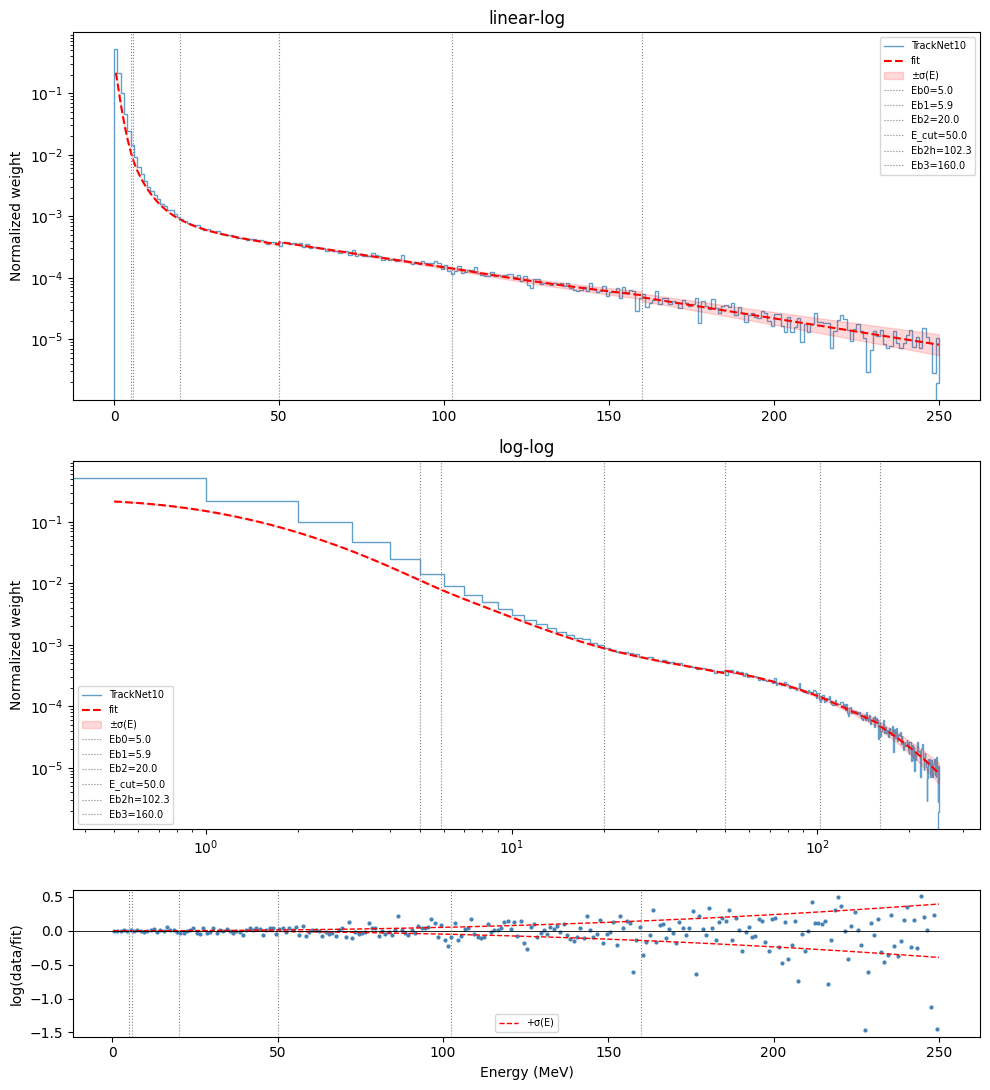


# Low-energy triply-broken PL (E < 50.0 MeV):
A_l=3.4444e+02, Eb0=5.0000, a1=-1.5799, a2=6.5836, s0=0.5467
Eb1=5.8521, a3=5.7953, s1=9.1866
Eb2=20.0000, a4=1.3958, s2=2.2124, Ec=56.1726

# High-energy (E >= 50.0 MeV):
A_h=9.7272e-04, E_h=53.1989, Eb2_h=102.2867, alpha2=2.2604
S3=1.0039, Eb3=160.0000, E4=50.7129, S4=0.9245

C_sigma=1.5207e-06, a_sigma=2.2575


In [65]:
from scipy.optimize import curve_fit
import numpy as np
import matplotlib.pyplot as plt

track_name, df = df_list[10]   # TrackNet10
E_centers = ((df['lower'] + df['upper']) / 2).values
TrackNeut10 = (df['weight'] / df['weight'].sum()).values

E_cut = 50.0

# ── Vertical offset (multiplicative) ─────────────────────────────────────────
vertical_offset = 1.00  # <-- adjust this to shift the entire fit up/down

# ── Low-energy (0–50 MeV): triply-broken power law × exp ─────────────────────
# f(E) = A · (E/Eb0)^(-a1)
#          · (1+(E/Eb0)^s0)^((a1-a2)/s0)   Eb0 in (0,  5)
#          · (1+(E/Eb1)^s1)^((a2-a3)/s1)   Eb1 in (5,  20)
#          · (1+(E/Eb2)^s2)^((a3-a4)/s2)   Eb2 in (20, 50)
#          · exp(-E/Ec)
mask_low = (TrackNeut10 > 0) & (E_centers > 0) & (E_centers < E_cut)
E_low, F_low = E_centers[mask_low], TrackNeut10[mask_low]

def smooth_tbpl(E, A, Eb0, a1, a2, s0, Eb1, a3, s1, Eb2, a4, s2, Ec):
    x0 = E / Eb0
    x1 = E / Eb1
    x2 = E / Eb2
    return (A
            * x0**(-a1)
            * (1 + x0**s0)**((a1 - a2) / s0)
            * (1 + x1**s1)**((a2 - a3) / s1)
            * (1 + x2**s2)**((a3 - a4) / s2)
            * np.exp(-E / Ec))

#              A        Eb0   a1    a2   s0   Eb1   a3    s1   Eb2   a4    s2   Ec
p0     = [F_low[0],  2.0,  1.0,  0.5, 2.0,  8.0,  0.1, 2.0, 25.0, -0.3, 2.0, 40.0]
bounds = ([0,    0,   -np.inf,-np.inf,0.1,  5, -np.inf,0.1, 20, -np.inf,0.1,  0],
          [np.inf, 5,  np.inf, np.inf,20,  20,  np.inf,20,  50,  np.inf,20, np.inf])

popt_low, pcov_low = curve_fit(smooth_tbpl, E_low, F_low,
                                p0=p0, bounds=bounds, maxfev=1000000)
perr_low = np.sqrt(np.diag(pcov_low))
A_l, Eb0_l, a1_l, a2_l, s0_l, Eb1_l, a3_l, s1_l, Eb2_l, a4_l, s2_l, Ec_l = popt_low

print('Low-energy triply-broken PL fit (0–50 MeV):')
for lbl, v, e in zip(['A','Eb0','a1','a2','s0','Eb1','a3','s1','Eb2','a4','s2','Ec'], popt_low, perr_low):
    print(f'  {lbl:4s} = {v:.4e} ± {e:.2e}')
print(f'  [Eb0 in 0–5, Eb1 in 5–20, Eb2 in 20–50 MeV]')

# ── High-energy (>=50 MeV): exp → power law (S3) → exp (S4) ─────────────────
mask_high = (TrackNeut10 > 0) & (E_centers >= E_cut)
E_high, F_high = E_centers[mask_high], TrackNeut10[mask_high]

def piece_high(E, A_h, E_h, Eb2, alpha2, S3, Eb3, E4, S4):
    val_Eb2 = A_h * np.exp(-Eb2 / E_h)
    B2 = val_Eb2 * Eb2**alpha2;  A3 = S3 * B2
    val_Eb3 = A3 * Eb3**(-alpha2);  A4 = S4 * val_Eb3 * np.exp(Eb3 / E4)
    return np.select(
        [E < Eb2, (E >= Eb2) & (E < Eb3), E >= Eb3],
        [A_h * np.exp(-E / E_h),
         np.where(E > 0, A3 * E**(-alpha2), 0.0),
         A4 * np.exp(-E / E4)]
    )

p0_h     = [F_high[0], 47.0, 100.0, 2.0, 1.0, 160.0, 50.0, 1.0]
bounds_h = ([0, 0, E_cut, 0, 0, E_cut, 0, 0],
            [np.inf, np.inf, E_high.max(), np.inf, np.inf, E_high.max(), np.inf, np.inf])
popt_h, pcov_h = curve_fit(piece_high, E_high, F_high,
                            p0=p0_h, bounds=bounds_h, maxfev=500000)
A_h, E_h, Eb2_h, alpha2, S3, Eb3, E4, S4 = popt_h
val_Eb2_h = A_h * np.exp(-Eb2_h / E_h)
B2 = val_Eb2_h * Eb2_h**alpha2;  A3 = S3 * B2
val_Eb3 = A3 * Eb3**(-alpha2);  A4 = S4 * val_Eb3 * np.exp(Eb3 / E4)

print('\nHigh-energy fit (>=50 MeV):')
for lbl, v, e in zip(['A_h','E_h','Eb2','α2','S3','Eb3','E4','S4'], popt_h, np.sqrt(np.diag(pcov_h))):
    print(f'  {lbl:5s} = {v:.4e} ± {e:.2e}')

# ── Combined function (with vertical offset) ──────────────────────────────────
def piecewise_track10(E):
    E  = np.asarray(E, dtype=float)
    x0 = np.where(E > 0, E / Eb0_l, 1e-30)
    x1 = np.where(E > 0, E / Eb1_l, 1e-30)
    x2 = np.where(E > 0, E / Eb2_l, 1e-30)
    f_l = (A_l * x0**(-a1_l)
           * (1 + x0**s0_l)**((a1_l - a2_l) / s0_l)
           * (1 + x1**s1_l)**((a2_l - a3_l) / s1_l)
           * (1 + x2**s2_l)**((a3_l - a4_l) / s2_l)
           * np.exp(-E / Ec_l))
    f_h = np.where(E < Eb2_h,  A_h * np.exp(-E / E_h),
          np.where(E < Eb3,    np.where(E > 0, A3 * E**(-alpha2), 0.0),
                                A4  * np.exp(-E / E4)))
    return vertical_offset * np.where(E < E_cut, f_l, f_h)

# ── σ(E) = C·E^a ─────────────────────────────────────────────────────────────
mask_all = (TrackNeut10 > 0) & (E_centers > 0)
E_res    = E_centers[mask_all]
log_res  = np.log(TrackNeut10[mask_all]) - np.log(piecewise_track10(E_res))
popt_s, _ = curve_fit(lambda E, C, a: C * E**a, E_res, np.abs(log_res),
                       p0=[np.mean(np.abs(log_res)), 0.0], maxfev=50000)
C_s, a_s = popt_s
def sigma_E(E): return C_s * np.asarray(E, dtype=float)**a_s
print(f'\nσ(E) = {C_s:.4e} · E^{a_s:.4f}')
print(f'vertical_offset = {vertical_offset}')

# ── Plot ──────────────────────────────────────────────────────────────────────
bin_edges  = np.append(df['lower'].values, df['upper'].iloc[-1])
E_smooth   = np.linspace(0.5, 250, 2000)
f_smooth   = piecewise_track10(E_smooth)
sig_smooth = sigma_E(E_smooth)
vlines     = [Eb0_l, Eb1_l, Eb2_l, E_cut, Eb2_h, Eb3]
vlabels    = [f'Eb0={Eb0_l:.1f}', f'Eb1={Eb1_l:.1f}', f'Eb2={Eb2_l:.1f}',
              f'E_cut={E_cut}',    f'Eb2h={Eb2_h:.1f}', f'Eb3={Eb3:.1f}']

fig, axes = plt.subplots(3, 1, figsize=(10, 11),
                          gridspec_kw={'height_ratios': [2.5, 2.5, 1]})
for ax, (xscale, yscale) in zip(axes[:2], [('linear','log'), ('log','log')]):
    ax.stairs(TrackNeut10, bin_edges, label=track_name, alpha=0.7)
    ax.plot(E_smooth, f_smooth, 'r--', linewidth=1.5,
            label=f'fit × {vertical_offset}' if vertical_offset != 1.0 else 'fit')
    ax.fill_between(E_smooth,
                    f_smooth * np.exp(-sig_smooth),
                    f_smooth * np.exp( sig_smooth),
                    color='red', alpha=0.15, label='±σ(E)')
    for xv, lbl in zip(vlines, vlabels):
        ax.axvline(xv, color='gray', linestyle=':', linewidth=0.8, label=lbl)
    ax.set_xscale(xscale); ax.set_yscale(yscale)
    ax.set_ylabel('Normalized weight'); ax.set_title(f'{xscale}-{yscale}')
    ax.legend(fontsize=7)

axes[2].scatter(E_res, log_res, s=4, color='steelblue')
axes[2].plot(E_smooth,  sigma_E(E_smooth), 'r--', linewidth=1.0, label='+σ(E)')
axes[2].plot(E_smooth, -sigma_E(E_smooth), 'r--', linewidth=1.0)
axes[2].axhline(0, color='black', linewidth=0.6)
for xv in vlines: axes[2].axvline(xv, color='gray', linestyle=':', linewidth=0.8)
axes[2].set_ylabel('log(data/fit)'); axes[2].set_xlabel('Energy (MeV)')
axes[2].legend(fontsize=7)
plt.tight_layout()
plt.show()

print(f'\n# Low-energy triply-broken PL (E < {E_cut} MeV):')
print(f'A_l={A_l:.4e}, Eb0={Eb0_l:.4f}, a1={a1_l:.4f}, a2={a2_l:.4f}, s0={s0_l:.4f}')
print(f'Eb1={Eb1_l:.4f}, a3={a3_l:.4f}, s1={s1_l:.4f}')
print(f'Eb2={Eb2_l:.4f}, a4={a4_l:.4f}, s2={s2_l:.4f}, Ec={Ec_l:.4f}')
print(f'\n# High-energy (E >= {E_cut} MeV):')
print(f'A_h={A_h:.4e}, E_h={E_h:.4f}, Eb2_h={Eb2_h:.4f}, alpha2={alpha2:.4f}')
print(f'S3={S3:.4f}, Eb3={Eb3:.4f}, E4={E4:.4f}, S4={S4:.4f}')
print(f'\nC_sigma={C_s:.4e}, a_sigma={a_s:.4f}')


In [66]:
def power_law_cutoff(E, A, alpha, Ec):
    return A * E**(-alpha) * np.exp(-E / Ec)

p0 = [A_pl, alpha_pl, E_fit.mean()]
popt_plc, pcov_plc = curve_fit(power_law_cutoff, E_fit, F_fit, p0=p0, maxfev=20000)
A_plc, alpha_plc, Ec_plc = popt_plc
perr_plc = np.sqrt(np.diag(pcov_plc))
print(f'Power law + cutoff:  A={A_plc:.4e}±{perr_plc[0]:.2e}  α={alpha_plc:.4f}±{perr_plc[1]:.4f}  Ec={Ec_plc:.4f}±{perr_plc[2]:.4f}')

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 7), sharex=True,
                               gridspec_kw={'height_ratios': [3, 1]})

ax1.stairs(TrackNeut10, bin_edges, label=track_name, alpha=0.7)
E_smooth = np.linspace(E_fit.min(), E_fit.max(), 500)
ax1.plot(E_smooth, power_law_cutoff(E_smooth, *popt_plc), 'r--',
         label=f'A={A_plc:.3e}, α={alpha_plc:.3f}, Ec={Ec_plc:.3f}')
ax1.set_ylabel('Normalized weight')
ax1.set_yscale('log')
ax1.set_title(f'{track_name} — Power law + exponential cutoff')
ax1.legend()

residuals_plc = F_fit - power_law_cutoff(E_fit, *popt_plc)
ax2.scatter(E_fit, residuals_plc, s=4, color='steelblue')
ax2.axhline(0, color='r', linestyle='--', linewidth=0.8)
ax2.set_ylabel('Residuals')
ax2.set_xlabel('Energy (MeV × 10³)')
plt.tight_layout()
plt.show()

NameError: name 'A_pl' is not defined

In [68]:
import os

out_dir = Path('/Users/arjun/Python_Codes_Refactored/shielding-ml/analysis/track_outputs')
out_dir.mkdir(exist_ok=True)

for track_name, df in df_list[:10]:
    fpath = out_dir / f'{track_name}.txt'
    with open(fpath, 'w') as f:
        f.write('# lower_MeV  upper_MeV  weight\n')
        for _, row in df.iterrows():
            f.write(f'{row["upper"]:.6e}  {row["lower"]:.6e}  {row["weight"]:.6e}\n')
    print(f'Written: {fpath}')


Written: /Users/arjun/Python_Codes_Refactored/shielding-ml/analysis/track_outputs/TrackNeut.txt
Written: /Users/arjun/Python_Codes_Refactored/shielding-ml/analysis/track_outputs/TrackNeut1.txt
Written: /Users/arjun/Python_Codes_Refactored/shielding-ml/analysis/track_outputs/TrackNeut2.txt
Written: /Users/arjun/Python_Codes_Refactored/shielding-ml/analysis/track_outputs/TrackNeut3.txt
Written: /Users/arjun/Python_Codes_Refactored/shielding-ml/analysis/track_outputs/TrackNeut4.txt
Written: /Users/arjun/Python_Codes_Refactored/shielding-ml/analysis/track_outputs/TrackNeut5.txt
Written: /Users/arjun/Python_Codes_Refactored/shielding-ml/analysis/track_outputs/TrackNeut6.txt
Written: /Users/arjun/Python_Codes_Refactored/shielding-ml/analysis/track_outputs/TrackNeut7.txt
Written: /Users/arjun/Python_Codes_Refactored/shielding-ml/analysis/track_outputs/TrackNeut8.txt
Written: /Users/arjun/Python_Codes_Refactored/shielding-ml/analysis/track_outputs/TrackNeut9.txt


Text(0, 0.5, 'Ratio')

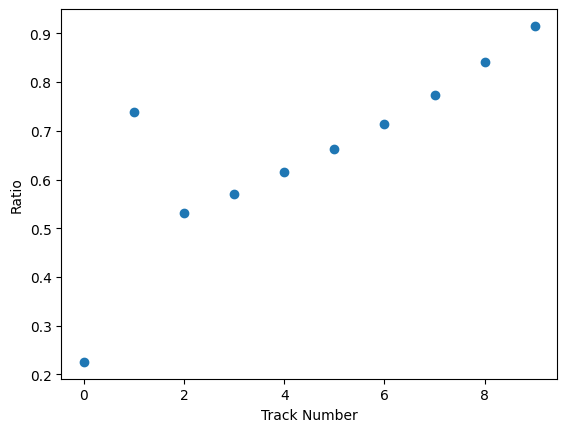

In [69]:
plt.scatter([i for i in range (0, 10)], [np.mean(x) for x in ratios.values()])
plt.xlabel("Track Number")
plt.ylabel("Ratio")

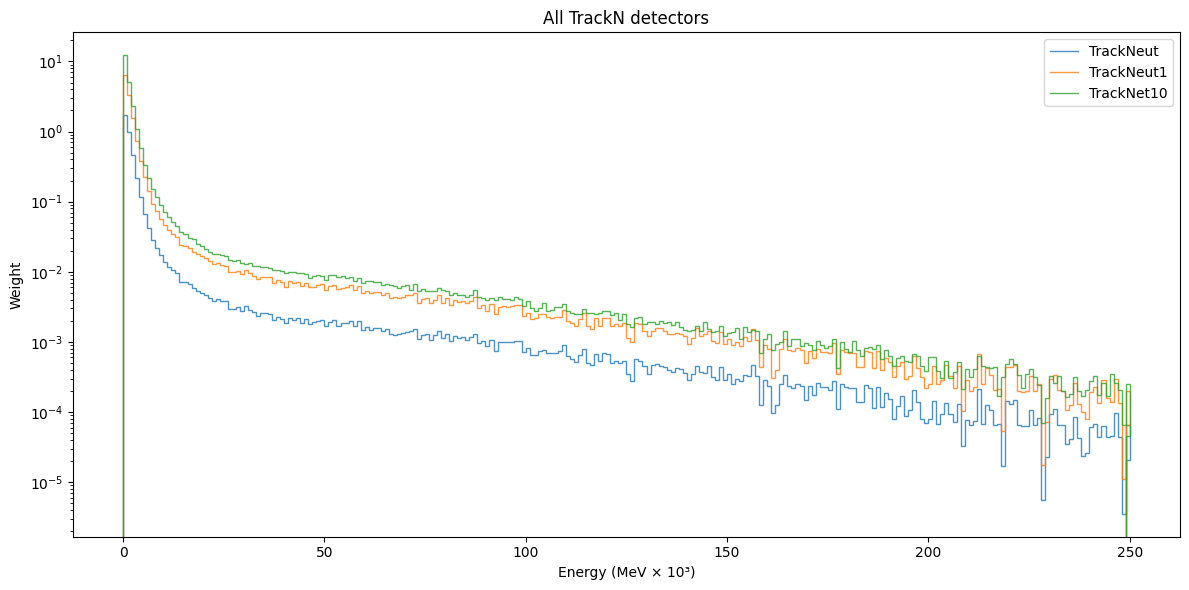

In [70]:
fig, ax = plt.subplots(figsize=(12, 6))
for track_name, df in [df_list[0], df_list[1], df_list[10]]:
    bin_edges = np.append(df['lower'].values, df['upper'].iloc[-1])
    ax.stairs(df['weight'].values, bin_edges, label=track_name, alpha=0.8)

ax.set_xlabel('Energy (MeV × 10³)')
ax.set_ylabel('Weight')
ax.set_title('All TrackN detectors')
ax.set_yscale('log')
ax.legend()
plt.tight_layout()
plt.show()

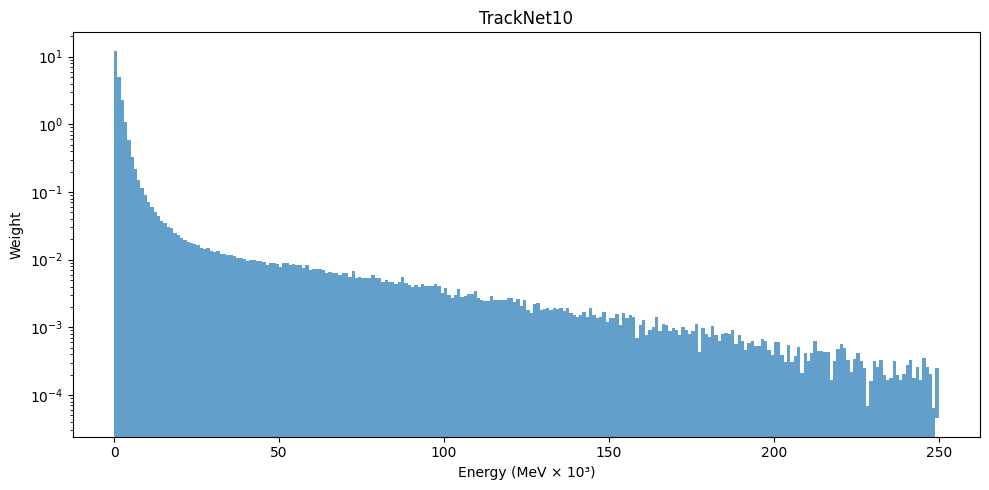

In [71]:
bin_edges = np.append(df['lower'].values, df['upper'].iloc[-1])

fig, ax = plt.subplots(figsize=(10, 5))
ax.stairs(df['weight'].values, bin_edges, fill=True, alpha=0.7)
ax.set_xlabel('Energy (MeV × 10³)')
ax.set_ylabel('Weight')
ax.set_title(track_name)
ax.set_yscale('log')
plt.tight_layout()
plt.show()

Fitting Concrete 45cm ...


/var/folders/wr/p4g_vhcn34g6101bsy9rmsd40000gn/T/ipykernel_31061/2402496811.py:29: OptimizeWarning: Covariance of the parameters could not be estimated
  popt_l, _ = curve_fit(smooth_tbpl, El, Fl, p0=p0_l, bounds=bnd_l, maxfev=2000000)


Fitting Steel 27cm ...
Fitting BPE 25cm ...

Concrete 45cm  (E_cut=10.0)
  low : Eb0=1.90  Eb1=3.46  Eb2=4.00  Ec=166.19
  high: E_h=171.15  Eb2=51.57  Eb3=129.69

Steel 27cm  (E_cut=10.0)
  low : Eb0=0.67  Eb1=2.62  Eb2=9.62  Ec=5.95
  high: E_h=40.80  Eb2=53.20  Eb3=129.68

BPE 25cm  (E_cut=10.0)
  low : Eb0=0.90  Eb1=4.00  Eb2=5.59  Ec=28.96
  high: E_h=47.30  Eb2=50.62  Eb3=125.89


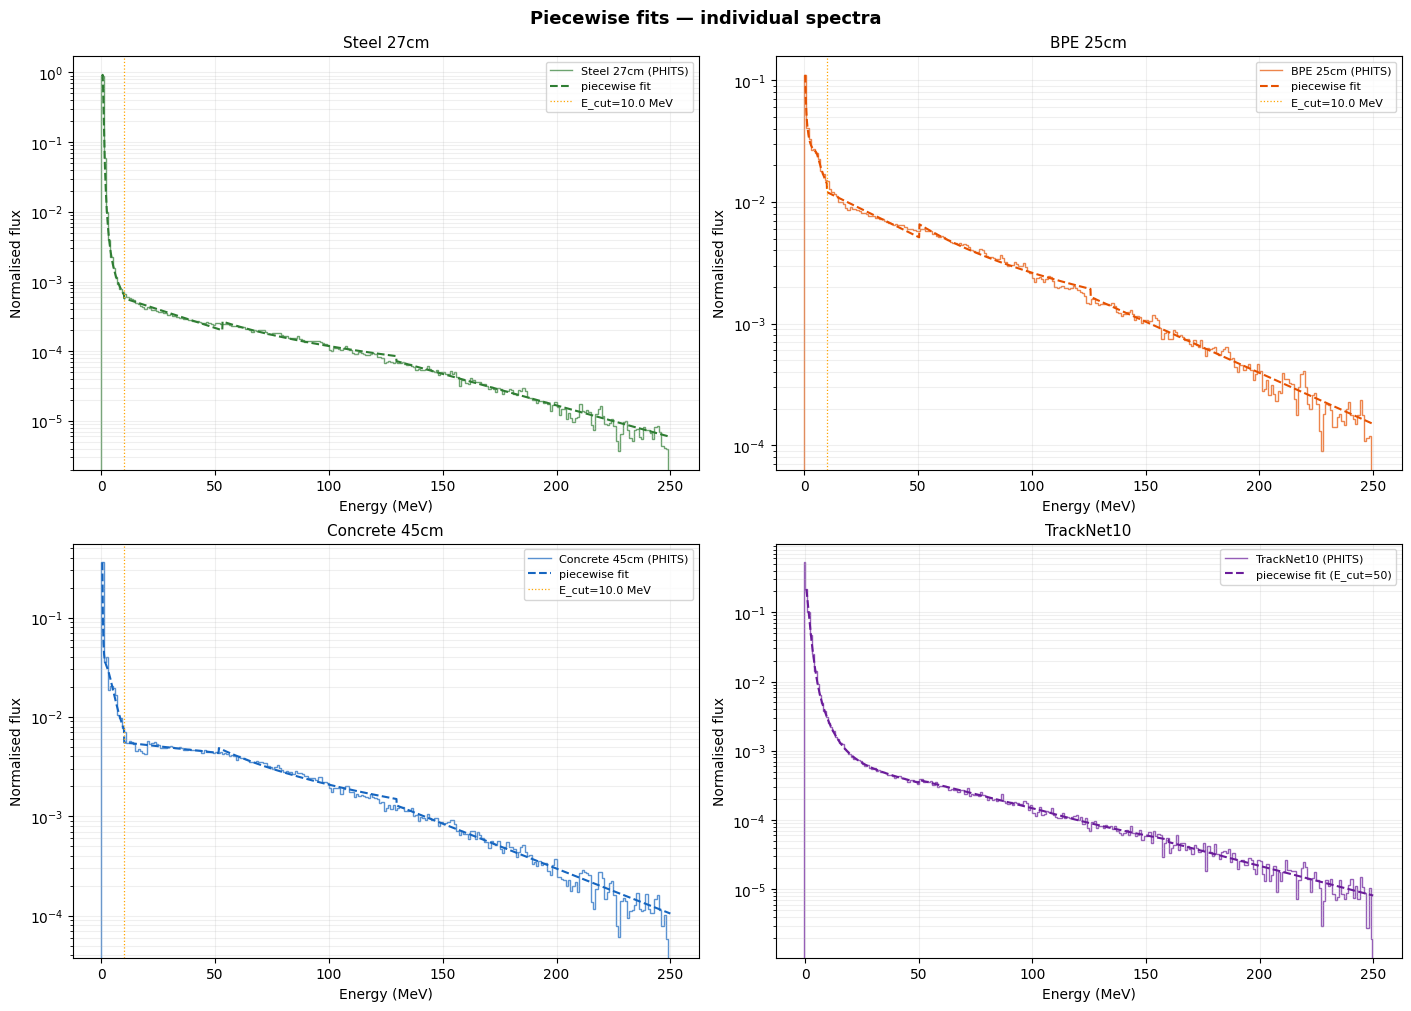

In [72]:

import sys
from pathlib import Path
sys.path.insert(0, str(Path('..').resolve()))

from shielding_ml.data.loaders import load_phits
from shielding_ml.pipelines.paths import PHITS_HE

# ── Load all spectra ──────────────────────────────────────────────────────────
def _load_norm(fname):
    raw, _ = load_phits(str(PHITS_HE / fname))
    return raw / raw.sum()

E_ax   = np.linspace(0.5, 249.5, 250)   # shared energy axis
F_c45  = _load_norm('Concrete_45cm_1.out')
F_s27  = _load_norm('Steel_27cm_1.out')
F_bpe  = _load_norm('BPE_25cm.out')

E_cut_shielded = 10.0
E_cut_t10      = 50.0

# ── Piecewise fit helper ──────────────────────────────────────────────────────
def fit_piecewise(F, E_centers, E_cut, label=''):
    mk_l = (F > 0) & (E_centers > 0) & (E_centers < E_cut)
    El, Fl = E_centers[mk_l], F[mk_l]
    p0_l  = [Fl[0], 0.8, 1.0, 0.5, 2.0, 3.0, 0.1, 2.0, max(E_cut*0.7, 4), -0.3, 2.0, E_cut*0.9]
    bnd_l = ([0,  0,   -np.inf,-np.inf,0.1, E_cut*0.2,-np.inf,0.1, E_cut*0.4,-np.inf,0.1,  0],
             [np.inf, E_cut*0.2, np.inf, np.inf,20, E_cut*0.5, np.inf,20, E_cut, np.inf,20, np.inf])
    try:
        popt_l, _ = curve_fit(smooth_tbpl, El, Fl, p0=p0_l, bounds=bnd_l, maxfev=2000000)
    except Exception as e:
        print(f'  [{label}] low-energy fit failed: {e}'); return None
    A_l,Eb0_l,a1_l,a2_l,s0_l,Eb1_l,a3_l,s1_l,Eb2_l,a4_l,s2_l,Ec_l = popt_l

    mk_h = (F > 0) & (E_centers >= E_cut)
    Eh, Fh = E_centers[mk_h], F[mk_h]
    p0_h  = [Fh[0], 15.0, min(50.0, Eh.max()*0.4), 2.0, 1.0, min(130.0, Eh.max()*0.8), 40.0, 1.0]
    bnd_h = ([0, 0, E_cut, 0, 0, E_cut, 0, 0],
             [np.inf, np.inf, Eh.max(), np.inf, np.inf, Eh.max(), np.inf, np.inf])
    try:
        popt_h, _ = curve_fit(piece_high, Eh, Fh, p0=p0_h, bounds=bnd_h, maxfev=500000)
    except Exception as e:
        print(f'  [{label}] high-energy fit failed: {e}'); return None
    A_h,E_h,Eb2_h,al2,S3,Eb3,E4,S4 = popt_h

    vEb2 = A_h * np.exp(-Eb2_h / E_h)
    B2   = vEb2 * Eb2_h**al2;  A3 = S3 * B2
    vEb3 = A3   * Eb3**(-al2);  A4 = S4 * vEb3 * np.exp(Eb3 / E4)

    def _func(E):
        E  = np.asarray(E, dtype=float)
        x0 = np.where(E > 0, E / Eb0_l, 1e-30)
        x1 = np.where(E > 0, E / Eb1_l, 1e-30)
        x2 = np.where(E > 0, E / Eb2_l, 1e-30)
        fl = (A_l * x0**(-a1_l)
              * (1 + x0**s0_l)**((a1_l-a2_l)/s0_l)
              * (1 + x1**s1_l)**((a2_l-a3_l)/s1_l)
              * (1 + x2**s2_l)**((a3_l-a4_l)/s2_l)
              * np.exp(-E / Ec_l))
        fh = np.where(E < Eb2_h,  A_h * np.exp(-E / E_h),
             np.where(E < Eb3,    np.where(E > 0, A3 * E**(-al2), 0.0),
                                   A4  * np.exp(-E / E4)))
        return np.where(E < E_cut, fl, fh)

    _func.popt_low  = popt_l
    _func.popt_high = popt_h
    _func.E_cut     = E_cut
    return _func

# ── Fit spectra ───────────────────────────────────────────────────────────────
print('Fitting Concrete 45cm ...')
piecewise_concrete45 = fit_piecewise(F_c45, E_ax, E_cut_shielded, 'Concrete 45cm')
print('Fitting Steel 27cm ...')
piecewise_steel27    = fit_piecewise(F_s27, E_ax, E_cut_shielded, 'Steel 27cm')
print('Fitting BPE 25cm ...')
piecewise_bpe25      = fit_piecewise(F_bpe, E_ax, E_cut_shielded, 'BPE 25cm')

for lbl, fn in [('Concrete 45cm', piecewise_concrete45),
                ('Steel 27cm',    piecewise_steel27),
                ('BPE 25cm',      piecewise_bpe25)]:
    if fn is not None:
        l = fn.popt_low; h = fn.popt_high
        print(f'\n{lbl}  (E_cut={fn.E_cut})')
        print(f'  low : Eb0={l[1]:.2f}  Eb1={l[5]:.2f}  Eb2={l[8]:.2f}  Ec={l[11]:.2f}')
        print(f'  high: E_h={h[1]:.2f}  Eb2={h[2]:.2f}  Eb3={h[5]:.2f}')

# ── 2×2 plot ─────────────────────────────────────────────────────────────────
E_sm  = np.linspace(0.5, 250, 2000)
edges = np.append(E_ax - 0.5, 249.5)

PANELS = [
    ('Steel 27cm',    F_s27, piecewise_steel27,    '#2E7D32'),
    ('BPE 25cm',      F_bpe, piecewise_bpe25,      '#E65100'),
    ('Concrete 45cm', F_c45, piecewise_concrete45,  '#1565C0'),
    ('TrackNet10',    None,  None,                  '#6A1B9A'),
]

fig, axes = plt.subplots(2, 2, figsize=(14, 10), constrained_layout=True)
fig.suptitle('Piecewise fits — individual spectra', fontsize=13, fontweight='bold')

for ax, (lbl, F_data, fn, col) in zip(axes.flat, PANELS):
    if lbl == 'TrackNet10':
        try:
            ax.stairs(TrackNeut10, np.append(E_centers - 0.5, 249.5),
                      label='TrackNet10 (PHITS)', alpha=0.7, color=col)
            ax.plot(E_sm, piecewise_track10(E_sm), '--', color=col,
                    linewidth=1.5, label='piecewise fit (E_cut=50)')
        except NameError:
            _tn, _df = df_list[10]
            _F  = (_df['weight'] / _df['weight'].sum()).values
            _ed = np.append(_df['lower'].values, _df['upper'].iloc[-1])
            ax.stairs(_F, _ed, label='TrackNet10 (PHITS)', alpha=0.7, color=col)
            ax.text(0.5, 0.5, 'Run fitting cell first\nfor TrackNet10 fit',
                    transform=ax.transAxes, ha='center', va='center', fontsize=9, color='gray')
    else:
        ax.stairs(F_data, edges, label=f'{lbl} (PHITS)', alpha=0.7, color=col)
        if fn is not None:
            ax.plot(E_sm, fn(E_sm), '--', color=col, linewidth=1.5, label='piecewise fit')
            ax.axvline(fn.E_cut, color='orange', linestyle=':', linewidth=0.9,
                       label=f'E_cut={fn.E_cut} MeV')
        else:
            ax.text(0.5, 0.5, 'Fit failed', transform=ax.transAxes,
                    ha='center', va='center', fontsize=10, color='red')
    ax.set_yscale('log')
    ax.set_xlabel('Energy (MeV)')
    ax.set_ylabel('Normalised flux')
    ax.set_title(lbl, fontsize=11)
    ax.legend(fontsize=8)
    ax.grid(True, which='both', alpha=0.2)

plt.show()


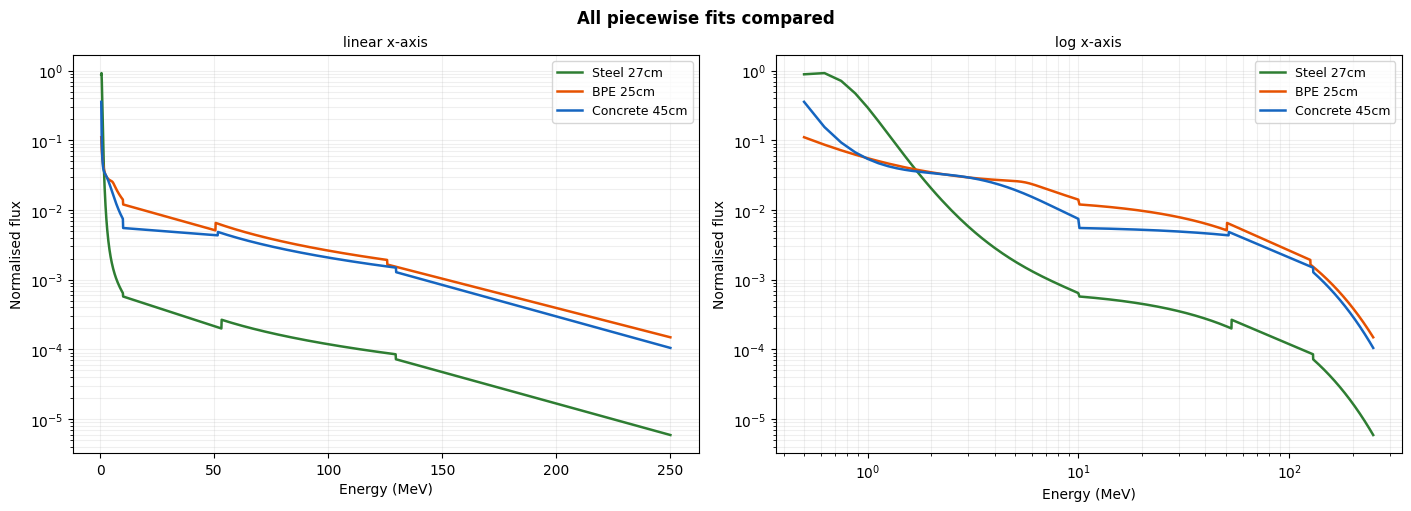

In [73]:

# ── All piecewise fits on one graph ──────────────────────────────────────────
E_sm = np.linspace(0.5, 250, 2000)

FITS = [
    ('Steel 27cm',    piecewise_steel27,    '#2E7D32'),
    ('BPE 25cm',      piecewise_bpe25,      '#E65100'),
    ('Concrete 45cm', piecewise_concrete45, '#1565C0'),
]

fig, axes = plt.subplots(1, 2, figsize=(14, 5), constrained_layout=True)
fig.suptitle('All piecewise fits compared', fontsize=12, fontweight='bold')

for ax, (xscale, title) in zip(axes, [('linear', 'linear x-axis'), ('log', 'log x-axis')]):
    for lbl, fn, col in FITS:
        if fn is not None:
            ax.plot(E_sm, fn(E_sm), linewidth=1.8, color=col, label=lbl)
    ax.set_yscale('log')
    ax.set_xscale(xscale)
    ax.set_xlabel('Energy (MeV)')
    ax.set_ylabel('Normalised flux')
    ax.set_title(title, fontsize=10)
    ax.legend(fontsize=9)
    ax.grid(True, which='both', alpha=0.2)

plt.show()
